Static Multi-step Forecast

--- BƯỚC 1: UPLOAD DỮ LIỆU (BẮT BUỘC LÀM LẦN LƯỢT) ---

👉 1. Vui lòng Upload 3 file CSV Ngân hàng (JPM, BAC, WFC...):


Saving BAC.csv to BAC.csv
Saving JPM.csv to JPM.csv
Saving WFC.csv to WFC.csv

👉 2. Vui lòng Upload file SPX500.csv:


Saving SPX500.csv to SPX500.csv

👉 3. Vui lòng Upload file FED (EFFR):


Saving FED_RATE.csv to FED_RATE.csv

👉 4. Vui lòng Upload file Sentiment:


Saving Dữ liệu hành vi.csv to Dữ liệu hành vi.csv

✅ ĐÃ UPLOAD ĐỦ 4 LOẠI FILE! TIẾP TỤC XỬ LÝ...
  > Tìm thấy cột ngày: 'Date'. Đang chuẩn hóa...
  > Tìm thấy cột ngày: 'Date'. Đang chuẩn hóa...
  > Tìm thấy cột ngày: 'date'. Đang chuẩn hóa...

> Xử lý dữ liệu ngoại sinh thành công!

######################################################################
  ĐANG XỬ LÝ: BAC.csv
######################################################################
  > Tìm thấy cột ngày: 'Date'. Đang chuẩn hóa...
  > Split: Train=1581 mẫu, Test=396 mẫu
  > Đang chạy: Monthly SARIMAX (s=22)...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


    -> Xong! RMSE(Test): 3.15 | MAPE(Test): 5.96%


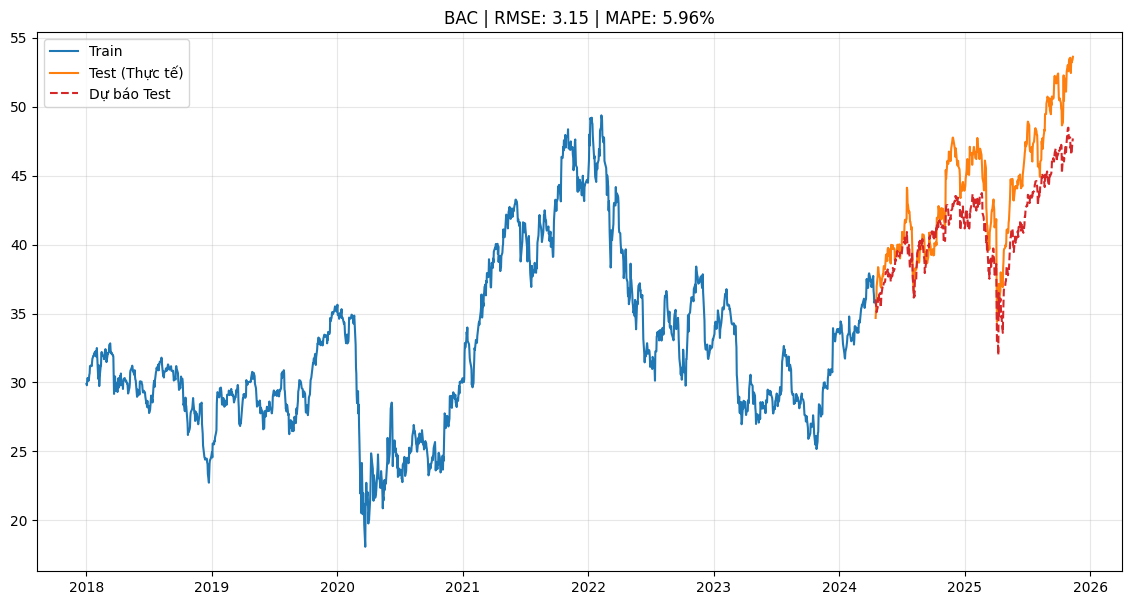

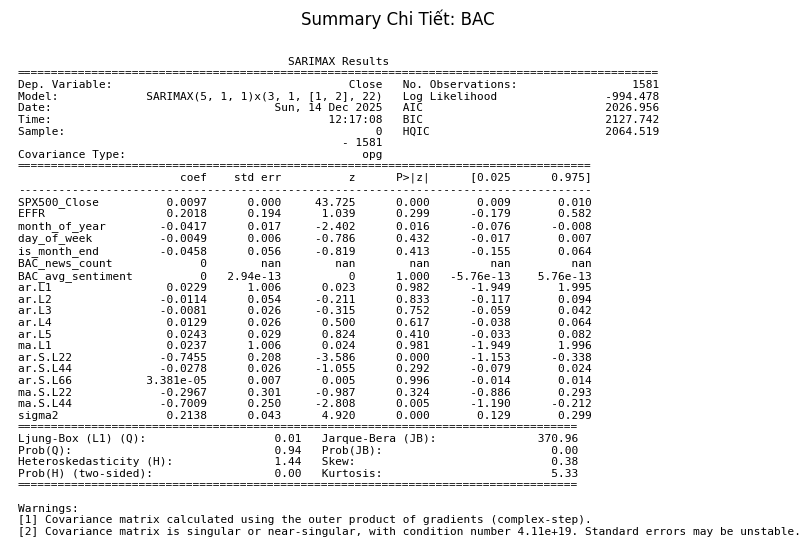


######################################################################
  ĐANG XỬ LÝ: JPM.csv
######################################################################
  > Tìm thấy cột ngày: 'Date'. Đang chuẩn hóa...
  > Split: Train=1581 mẫu, Test=396 mẫu
  > Đang chạy: Monthly SARIMAX (s=22)...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


    -> Xong! RMSE(Test): 45.95 | MAPE(Test): 14.47%


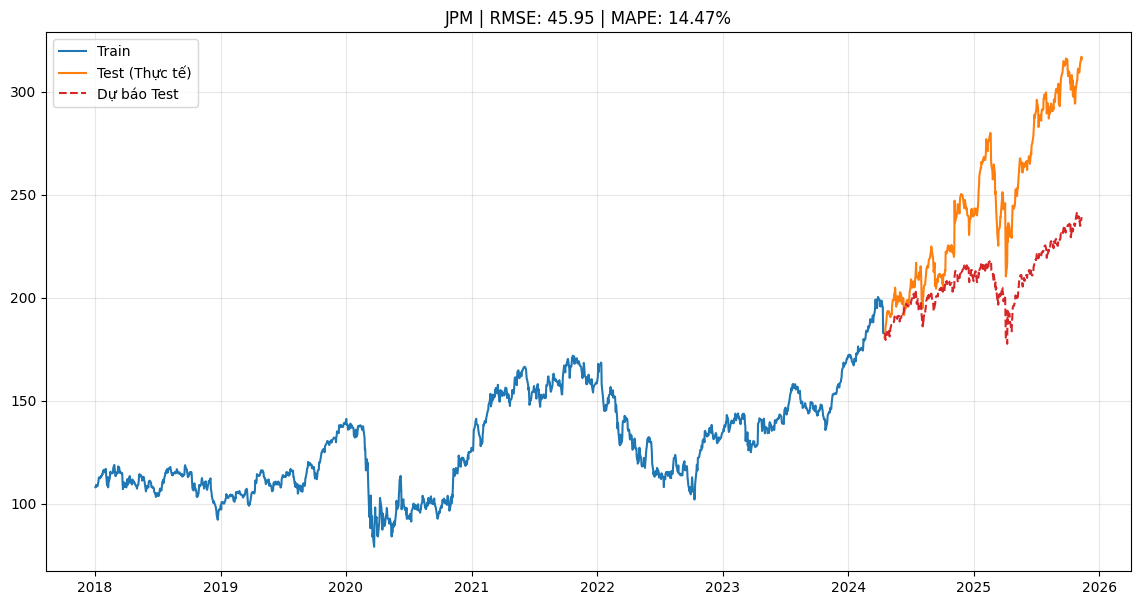

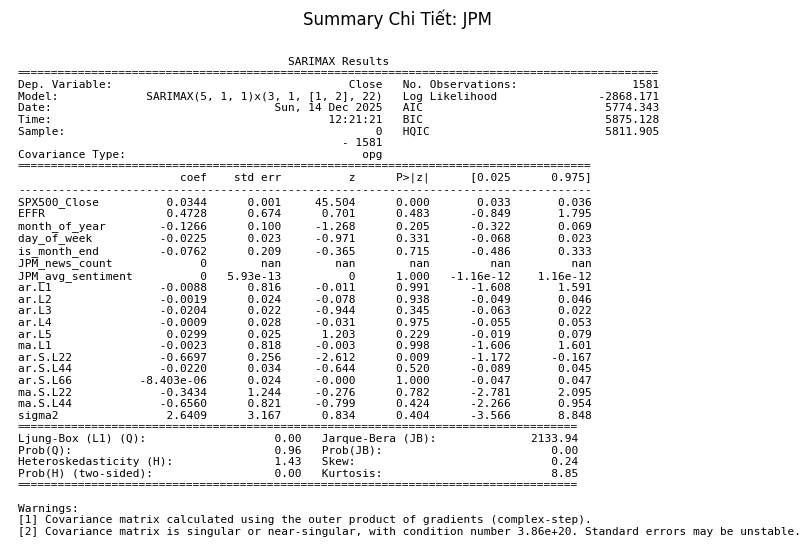


######################################################################
  ĐANG XỬ LÝ: WFC.csv
######################################################################
  > Tìm thấy cột ngày: 'Date'. Đang chuẩn hóa...
  > Split: Train=1579 mẫu, Test=395 mẫu
  > Đang chạy: Monthly SARIMAX (s=22)...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


    -> Xong! RMSE(Test): 8.66 | MAPE(Test): 10.28%


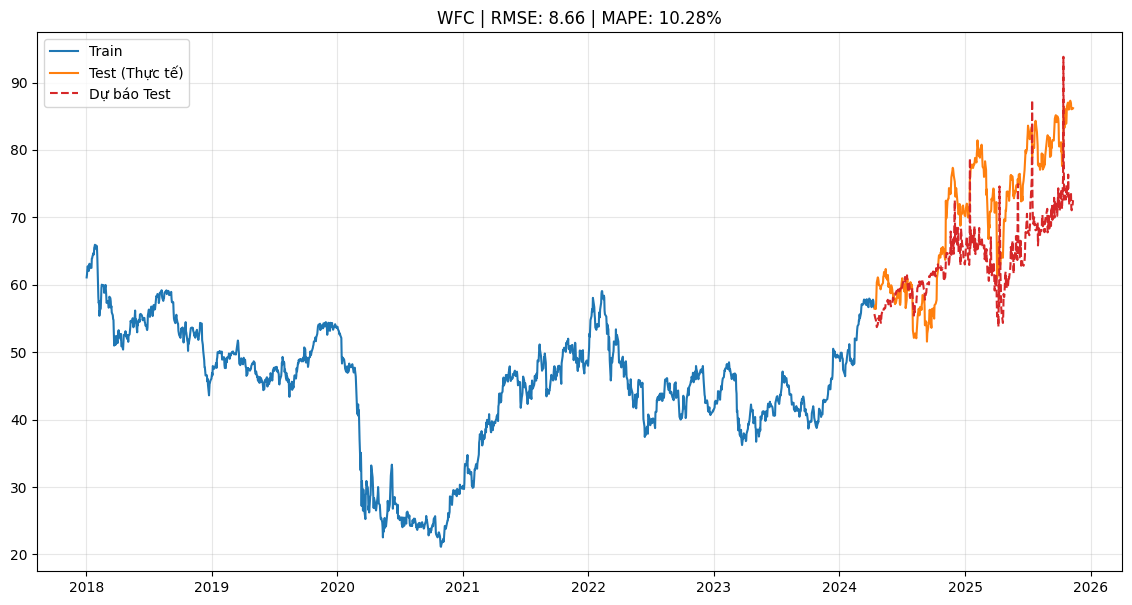

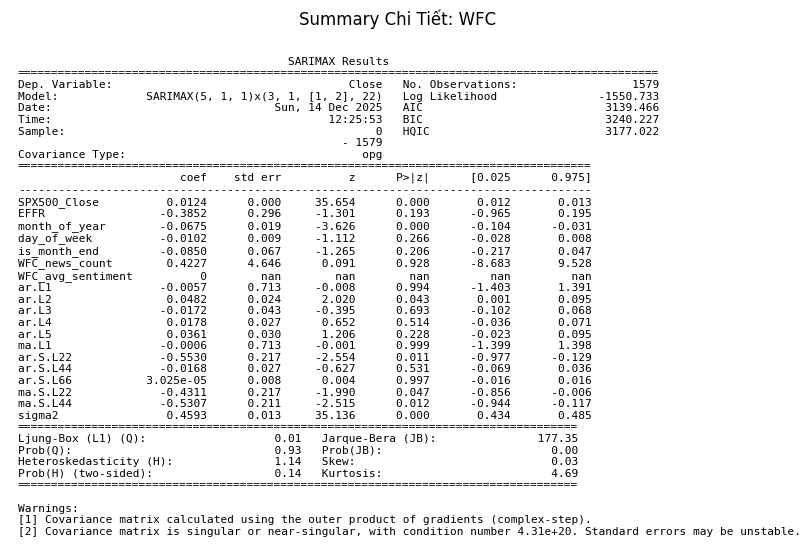


--- BẢNG TỔNG HỢP KẾT QUẢ ---
  Company                   Model  RMSE_Test MAPE_Test          AIC     Time(s)
0     BAC  Monthly SARIMAX (s=22)   3.152611     5.96%  2026.956137  291.034338
2     WFC  Monthly SARIMAX (s=22)   8.660808    10.28%  3139.466278  271.842415
1     JPM  Monthly SARIMAX (s=22)  45.951174    14.47%  5774.342565  252.096551


In [1]:
# ===========================
# IMPORTS & ENV SETUP
# ===========================
import os
os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"
import warnings
warnings.filterwarnings("ignore")

import io, gc, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import statsmodels.api as sm
from PIL import Image, ImageDraw, ImageFont

# ===========================
# 1. HÀM CHUẨN HÓA NGÀY (CÓ SORT & FIX LỖI)
# ===========================
def normalize_date_index(df):
    date_col = None
    # Tìm cột ngày linh hoạt
    for col in ['Date', 'date', 'observation_date', 'Time', 'time']:
        if col in df.columns:
            date_col = col
            break

    if date_col:
        print(f"  > Tìm thấy cột ngày: '{date_col}'. Đang chuẩn hóa...")
        df[date_col] = pd.to_datetime(df[date_col]).dt.normalize()
        df = df.set_index(date_col)
    elif df.index.name and 'date' in df.index.name.lower():
        df.index = pd.to_datetime(df.index).normalize()
    else:
        try:
            df.index = pd.to_datetime(df.index).normalize()
        except:
            raise ValueError("Không tìm thấy cột ngày hợp lệ.")

    # --- QUAN TRỌNG: SẮP XẾP TĂNG DẦN THEO THỜI GIAN ---
    df = df.sort_index()

    # Xử lý trùng lặp
    if not df.index.is_unique:
        print(f"    ! Cảnh báo: Ngày bị trùng lặp. Giữ lại dòng đầu tiên.")
        df = df[~df.index.duplicated(keep='first')]

    return df

# ===========================
# 2. HÀM VẼ ẢNH BÁO CÁO (SUMMARY)
# ===========================
def plot_summary_and_equation(res, config, company_name, final_exog_cols):
    try:
        # Tạo ảnh summary đơn giản từ text
        plt.figure(figsize=(10, 6))
        plt.text(0.01, 0.95, str(res.summary()), {'fontsize': 8}, fontproperties='monospace', va='top')
        plt.axis('off')
        plt.title(f"Summary Chi Tiết: {company_name}")
        plt.show()
    except Exception as e:
        print(f"Không thể vẽ ảnh summary: {e}")

# ===========================
# 3. CẤU HÌNH (ĐÃ FIX S=22 THÀNH S=0)
# ===========================
configs_to_test = [
    {
        "name": "Monthly SARIMAX (s=22)",
        "order": (5, 1, 1),
        "seasonal_order": (3, 1, 2, 22)
    }
]

# ===========================
# 4. UPLOAD FILE
# ===========================
# ===========================
# THAY THẾ CHO PHẦN UPLOAD CŨ
# ===========================

print("--- BƯỚC 1: UPLOAD DỮ LIỆU (BẮT BUỘC LÀM LẦN LƯỢT) ---")

# 1. Upload Ngân hàng
print("\n👉 1. Vui lòng Upload 3 file CSV Ngân hàng (JPM, BAC, WFC...):")
uploaded_banks = files.upload()
if not uploaded_banks: raise ValueError("❌ Bạn chưa upload file Ngân hàng! Dừng chương trình.")

# 2. Upload SPX500
print("\n👉 2. Vui lòng Upload file SPX500.csv:")
uploaded_spx = files.upload()
if not uploaded_spx: raise ValueError("❌ Bạn chưa upload file SPX500! Dừng chương trình.")

# 3. Upload FED
print("\n👉 3. Vui lòng Upload file FED (EFFR):")
uploaded_fed = files.upload()
if not uploaded_fed: raise ValueError("❌ Bạn chưa upload file FED! Dừng chương trình.")

# 4. Upload Sentiment
print("\n👉 4. Vui lòng Upload file Sentiment:")
uploaded_sentiment = files.upload()
if not uploaded_sentiment: raise ValueError("❌ Bạn chưa upload file Sentiment! Dừng chương trình.")

print("\n✅ ĐÃ UPLOAD ĐỦ 4 LOẠI FILE! TIẾP TỤC XỬ LÝ...")
# ===========================
# 5. XỬ LÝ DỮ LIỆU EXOG (MASTER)
# ===========================
try:
    # --- SPX500 ---
    spx_fn = next(iter(uploaded_spx))
    df_spx = pd.read_csv(io.BytesIO(uploaded_spx[spx_fn]))
    df_spx = normalize_date_index(df_spx)
    # Tìm cột giá thông minh
    potential_cols = ['Close', 'close', 'Last', 'last', 'Price', 'price']
    spx_col = next((c for c in potential_cols if c in df_spx.columns), df_spx.columns[0])
    df_spx = df_spx[[spx_col]].rename(columns={spx_col: 'SPX500_Close'})
    df_spx['SPX500_Close'] = pd.to_numeric(df_spx['SPX500_Close'], errors='coerce')

    # --- FED ---
    fed_fn = next(iter(uploaded_fed))
    df_fed = pd.read_csv(io.BytesIO(uploaded_fed[fed_fn]))
    df_fed = normalize_date_index(df_fed)
    df_fed = df_fed.iloc[:, [0]]
    df_fed.columns = ['EFFR']
    df_fed['EFFR'] = pd.to_numeric(df_fed['EFFR'], errors='coerce')

    # --- Sentiment ---
    sent_fn = next(iter(uploaded_sentiment))
    df_sent = pd.read_csv(io.BytesIO(uploaded_sentiment[sent_fn]))
    df_sent = normalize_date_index(df_sent)
    for col in df_sent.columns:
        df_sent[col] = pd.to_numeric(df_sent[col], errors='coerce')

    # --- Gộp Master Exog ---
    exog_master_df = pd.concat([df_spx, df_fed, df_sent], axis=1, join='outer')
    exog_master_df = exog_master_df.ffill().fillna(0)
    print("\n> Xử lý dữ liệu ngoại sinh thành công!")

except Exception as e:
    print(f"\nLỖI XỬ LÝ FILE: {e}")
    raise SystemExit("Dừng do lỗi dữ liệu đầu vào.")

# ===========================
# 6. MAIN LOOP (FULL TÍNH NĂNG)
# ===========================
# ===========================
# CODE ĐÃ SỬA: CHỈ CÒN TRAIN (90%) VÀ TEST (10%)
# ===========================

# ... (Giữ nguyên phần Import và Hàm chuẩn hóa ở trên) ...
# ... (Giữ nguyên phần Upload và Xử lý Exog ở trên) ...

# ===========================
# 6. MAIN LOOP (CHẾ ĐỘ 90/10 - KHÔNG VALIDATE)
# ===========================
series_name = 'Close'
master_summary_list = []

for file_name, file_content in uploaded_banks.items():
    print("\n" + "#"*70)
    print(f"  ĐANG XỬ LÝ: {file_name}")
    print("#"*70)
    company_name = os.path.splitext(file_name)[0]

    try:
        # --- 1. Đọc dữ liệu ---
        y_df = pd.read_csv(io.BytesIO(file_content))
        y_df = normalize_date_index(y_df)
        y_df[series_name] = pd.to_numeric(y_df[series_name], errors='coerce')

        # --- 2. Gộp với Exog ---
        df_full = y_df.join(exog_master_df, how='left')
        df_full.index = pd.to_datetime(df_full.index)

        # --- 3. Tạo biến thời gian & Chọn cột ---
        df_full['month_of_year'] = df_full.index.month
        df_full['day_of_week'] = df_full.index.dayofweek
        df_full['is_month_end'] = df_full.index.is_month_end.astype(int)

        base_exog = ['SPX500_Close', 'EFFR', 'month_of_year', 'day_of_week', 'is_month_end']
        company_prefix = company_name.split(" ")[0].split("(")[0]
        bank_sent_cols = [c for c in df_full.columns if c.startswith(company_prefix) and c not in [series_name]]
        final_exog_cols = base_exog + bank_sent_cols

        # Làm sạch
        df_full = df_full.dropna(subset=[series_name])
        df_full[final_exog_cols] = df_full[final_exog_cols].ffill().bfill()

        # --- 4. CHIA TRAIN/TEST (80/10) ---
        train_size = int(len(df_full) * 0.80) # 80% Train

        train = df_full.iloc[:train_size]
        test = df_full.iloc[train_size:]      # 20% Test (Không còn Validate)

        print(f"  > Split: Train={len(train)} mẫu, Test={len(test)} mẫu")

        # --- 5. CHẠY MÔ HÌNH ---
        for config in configs_to_test:
            print(f"  > Đang chạy: {config['name']}...")
            try:
                t0 = time.time()

                # Fit mô hình trên tập Train
                model = sm.tsa.SARIMAX(
                    train[series_name],
                    exog=train[final_exog_cols],
                    order=config['order'],
                    seasonal_order=config['seasonal_order'],
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                res = model.fit(disp=False)

                # Forecast (Chỉ dự báo cho phần Test)
                future_exog = test[final_exog_cols] # Exog của tương lai (Test)
                forecast = res.forecast(steps=len(test), exog=future_exog)

                preds_test = forecast # Toàn bộ forecast là cho Test

                # Chỉ số đánh giá (Chỉ tính cho Test)
                rmse_test = sqrt(mean_squared_error(test[series_name], preds_test))
                mape_test = mean_absolute_percentage_error(test[series_name], preds_test)

                aic = res.aic
                elapsed = time.time() - t0

                print(f"    -> Xong! RMSE(Test): {rmse_test:.2f} | MAPE(Test): {mape_test*100:.2f}%")

                # --- VẼ BIỂU ĐỒ (Chỉ Train và Test) ---
                plt.figure(figsize=(14,7))
                plt.plot(train.index, train[series_name], label='Train', color='#1f77b4')
                plt.plot(test.index, test[series_name], label='Test (Thực tế)', color='#ff7f0e')

                # Vẽ dự báo
                plt.plot(test.index, preds_test, label='Dự báo Test', color='#d62728', linestyle='--')

                plt.title(f"{company_name} | RMSE: {rmse_test:.2f} | MAPE: {mape_test*100:.2f}%")
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.show()

                # Vẽ bảng summary model
                plot_summary_and_equation(res, config, company_name, final_exog_cols)

                # Lưu vào list tổng (Bỏ các cột Val)
                master_summary_list.append({
                    'Company': company_name,
                    'Model': config['name'],
                    'RMSE_Test': rmse_test,
                    'MAPE_Test': f"{mape_test*100:.2f}%",
                    'AIC': aic,
                    'Time(s)': elapsed
                })

            except Exception as e:
                print(f"    -> Lỗi model: {e}")

    except Exception as e:
        print(f"  -> Bỏ qua file {file_name} do lỗi: {e}")

# ===========================
# 7. TỔNG HỢP CUỐI CÙNG
# ===========================
if master_summary_list:
    print("\n" + "="*80)
    print("--- BẢNG TỔNG HỢP KẾT QUẢ ---")
    print("="*80)
    df_summary = pd.DataFrame(master_summary_list)
    df_summary = df_summary.sort_values(by='RMSE_Test')
    print(df_summary.to_string())
else:
    print("Không có kết quả nào.")

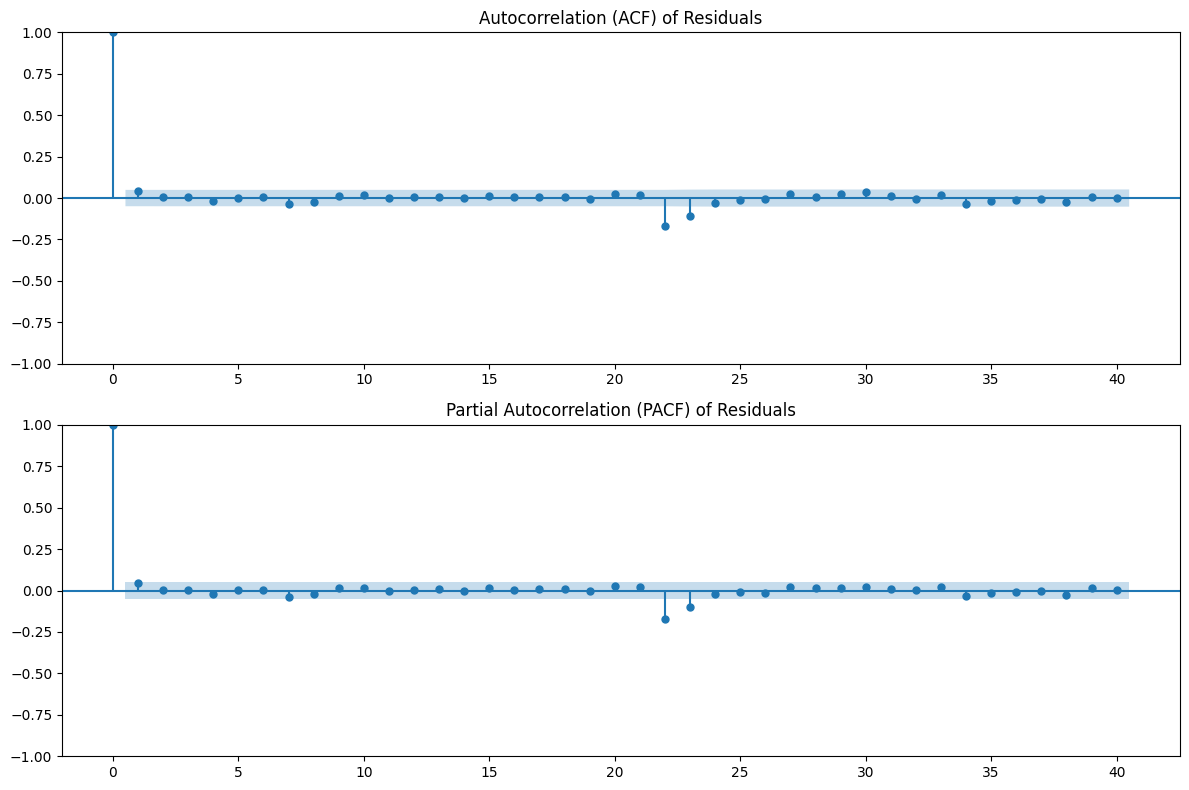


Ljung-Box Test Results:
      lb_stat     lb_pvalue
10   7.591960  6.686248e-01
20   9.542924  9.757234e-01
30  82.554164  8.426983e-07


In [2]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
# Visualize ACF and PACF of Residuals
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(res.resid, ax=ax1, lags=40, title="Autocorrelation (ACF) of Residuals")
plot_pacf(res.resid, ax=ax2, lags=40, title="Partial Autocorrelation (PACF) of Residuals")
plt.tight_layout()
plt.show()
# Ljung-Box Test
lb_test = acorr_ljungbox(res.resid, lags=[10, 20, 30], return_df=True)
print("\nLjung-Box Test Results:")
print(lb_test)